In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
sports = pd.read_csv('https://drive.google.com/uc?id=1rSoWPiYRshocgOYQZBDaTZG4Z7gRWqaL')
print(sports.head())
print(sports.describe())
print(sports.isnull().sum())

/tmp/ipython-input-2761770693.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  sports = pd.read_csv('https://drive.google.com/uc?id=1rSoWPiYRshocgOYQZBDaTZG4Z7gRWqaL')


   year  unitid          institution_name city_txt state_cd  zip_text  \
0  2015  100654  Alabama A & M University   Normal       AL   35762.0   
1  2015  100654  Alabama A & M University   Normal       AL   35762.0   
2  2015  100654  Alabama A & M University   Normal       AL   35762.0   
3  2015  100654  Alabama A & M University   Normal       AL   35762.0   
4  2015  100654  Alabama A & M University   Normal       AL   35762.0   

   classification_code  classification_name classification_other  \
0                    2  NCAA Division I-FCS                  NaN   
1                    2  NCAA Division I-FCS                  NaN   
2                    2  NCAA Division I-FCS                  NaN   
3                    2  NCAA Division I-FCS                  NaN   
4                    2  NCAA Division I-FCS                  NaN   

   ef_male_count  ...  partic_coed_women  sum_partic_men  sum_partic_women  \
0           1923  ...                NaN              31                 0

In [ ]:
sports_clean = sports.drop(columns=['unitid', 'city_txt', 'classification_code', 'classification_other', 'zip_text'])
sports_clean.head()

,year,institution_name,state_cd,classification_name,ef_male_count,ef_female_count,ef_total_count,sector_cd,sector_name,sportscode,...,partic_coed_women,sum_partic_men,sum_partic_women,rev_men,rev_women,total_rev_menwomen,exp_men,exp_women,total_exp_menwomen,sports
0,2015,Alabama A & M University,AL,NCAA Division I-FCS,1923,2300,4223,1,"Public, 4-year or above",1,...,NaN,31,0,345592.0,NaN,345592.0,397818.0,NaN,397818.0,Baseball
1,2015,Alabama A & M University,AL,NCAA Division I-FCS,1923,2300,4223,1,"Public, 4-year or above",2,...,NaN,19,16,1211095.0,748833.0,1959928.0,817868.0,742460.0,1560328.0,Basketball
2,2015,Alabama A & M University,AL,NCAA Division I-FCS,1923,2300,4223,1,"Public, 4-year or above",3,...,NaN,61,46,183333.0,315574.0,498907.0,246949.0,251184.0,498133.0,All Track Combined
3,2015,Alabama A & M University,AL,NCAA Division I-FCS,1923,2300,4223,1,"Public, 4-year or above",7,...,NaN,99,0,2808949.0,NaN,2808949.0,3059353.0,NaN,3059353.0,Football
4,2015,Alabama A & M University,AL,NCAA Division I-FCS,1923,2300,4223,1,"Public, 4-year or above",8,...,NaN,9,0,78270.0,NaN,78270.0,83913.0,NaN,83913.0,Golf


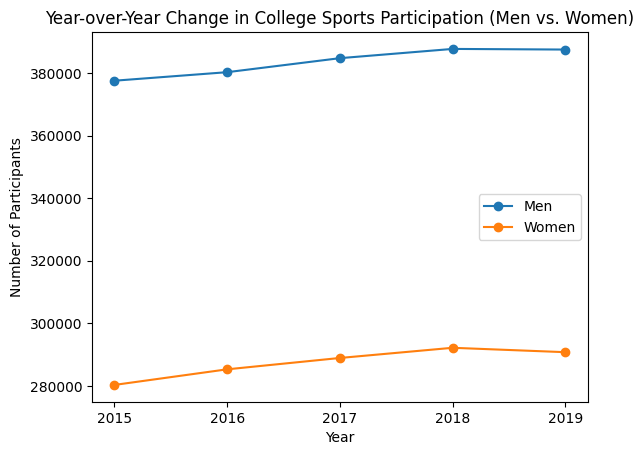

In [ ]:
yearly_participation = sports_clean.groupby("year")[["sum_partic_men", "sum_partic_women"]].sum()
plt.figure()
plt.plot(yearly_participation.index, yearly_participation["sum_partic_men"], label="Men", marker='o')
plt.plot(yearly_participation.index, yearly_participation["sum_partic_women"], label="Women", marker='o')
plt.title("Year-over-Year Change in College Sports Participation (Men vs. Women)")
plt.xlabel("Year")
plt.ylabel("Number of Participants")
plt.legend()
plt.xticks(yearly_participation.index)  # Show only whole years
plt.show()

In [ ]:
print("Yearly Participation:\n", yearly_participation)

Yearly Participation:
       sum_partic_men  sum_partic_women
year                                  
2015          377537            280283
2016          380261            285270
2017          384742            288900
2018          387698            292154
2019          387496            290749


In [ ]:
yearly_pct_change = yearly_participation.pct_change() * 100  # convert to percent
print("Year-over-Year Participation Change (%):")
print(yearly_pct_change.round(2))
print("Overall Participation Change (%) from 2015-2019:")
print(yearly_pct_change[['sum_partic_men', 'sum_partic_women']].sum())

#both participation growing 2016-2018, women faster than men and more than men overall
#male participation still over 100k people greater than female

#decline in 2018-2019:
    #budget cuts at universities, Title IX compliance issues?

Year-over-Year Participation Change (%):
      sum_partic_men  sum_partic_women
year                                  
2015             NaN               NaN
2016            0.72              1.78
2017            1.18              1.27
2018            0.77              1.13
2019           -0.05             -0.48
Overall Participation Change (%) from 2015-2019:
sum_partic_men      2.616125
sum_partic_women    3.697182
dtype: float64


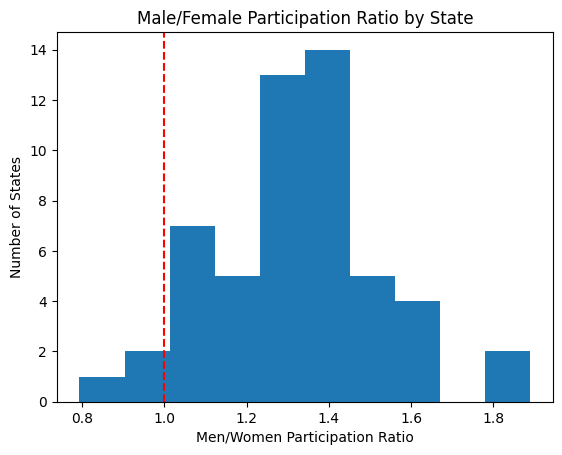

In [ ]:
# participation ratio by state
state_partic = sports_clean.groupby('state_cd')[['sum_partic_men', 'sum_partic_women']].sum().reset_index()
state_partic['men_women_partic_ratio'] = state_partic['sum_partic_men'] / state_partic['sum_partic_women']
state_partic.sort_values(by='men_women_partic_ratio', ascending=False)[:10]

plt.hist(state_partic['men_women_partic_ratio'])
plt.axvline(x=1, color='r', linestyle='--')
plt.title('Male/Female Participation Ratio by State')
plt.xlabel('Men/Women Participation Ratio')
plt.ylabel('Number of States')
plt.show()

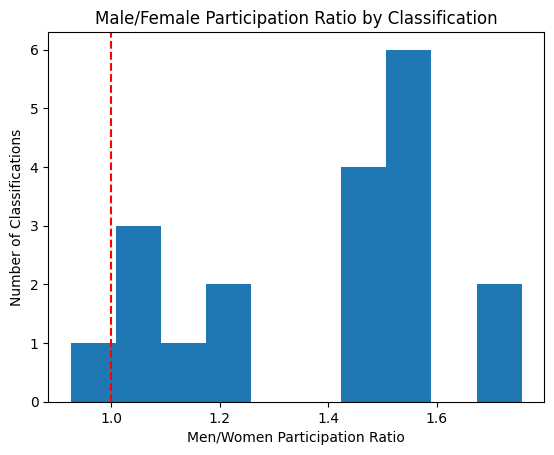

In [ ]:
# participation ratio by classification
classification_partic = sports_clean.groupby('classification_name')[['sum_partic_men', 'sum_partic_women']].sum().reset_index()
classification_partic['men_women_partic_ratio'] = classification_partic['sum_partic_men'] / classification_partic['sum_partic_women']
classification_partic.sort_values(by='men_women_partic_ratio', ascending=False)[:10]

plt.hist(classification_partic['men_women_partic_ratio'])
plt.axvline(x=1, color='r', linestyle='--')
plt.title('Male/Female Participation Ratio by Classification')
plt.xlabel('Men/Women Participation Ratio')
plt.ylabel('Number of Classifications')
plt.show()

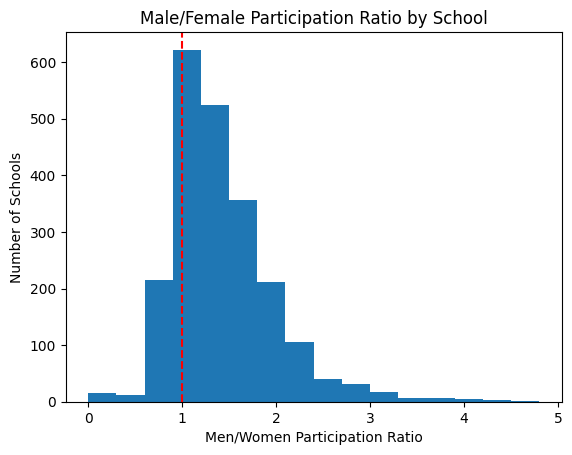

In [ ]:
# participation ratio by school
school_partic = sports_clean.groupby('institution_name')[['sum_partic_men', 'sum_partic_women']].sum().reset_index()
for i in range(len(school_partic)):
  if school_partic.loc[i, 'sum_partic_women'] == 0:
    school_partic.loc[i, 'men_women_partic_ratio'] = np.nan
  else:
    school_partic.loc[i, 'men_women_partic_ratio'] = school_partic.loc[i, 'sum_partic_men'] / school_partic.loc[i, 'sum_partic_women']
school_partic.sort_values(by='men_women_partic_ratio', ascending=False)[:10]

plt.hist(school_partic['men_women_partic_ratio'].dropna(), bins=np.arange(0, 5, 0.3))
plt.axvline(x=1, color='r', linestyle='--')
plt.title('Male/Female Participation Ratio by School')
plt.xlabel('Men/Women Participation Ratio')
plt.ylabel('Number of Schools')
plt.show()

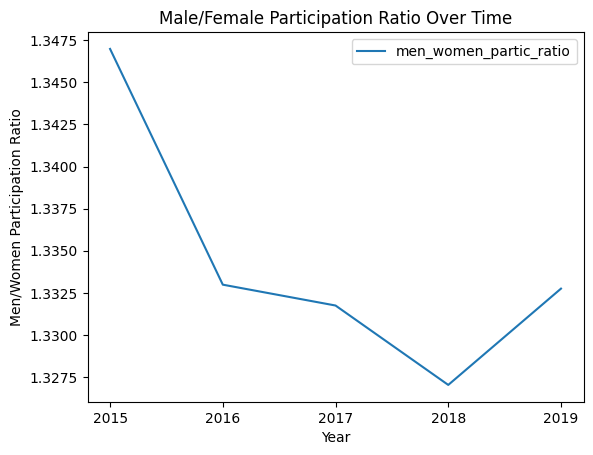

In [ ]:
#Overall participation ratio over time
time_partic = sports_clean.groupby('year')[['sum_partic_men', 'sum_partic_women']].sum().reset_index()
time_partic['men_women_partic_ratio'] = time_partic['sum_partic_men'] / time_partic['sum_partic_women']
time_partic.plot(x='year', y='men_women_partic_ratio')
plt.title('Male/Female Participation Ratio Over Time')
plt.xlabel('Year')
plt.ylabel('Men/Women Participation Ratio')
plt.xticks(time_partic['year'].unique())
plt.show()

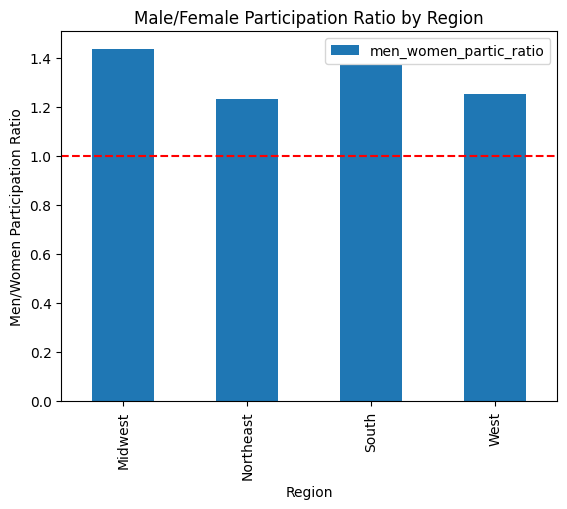

In [ ]:
#Participation Rate by Region
#50 States + DC
state_to_region = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 'RI': 'Northeast', 'VT': 'Northeast',
    'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South',
    'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 'UT': 'West', 'WY': 'West',
    'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

sports_clean ['region_name'] = sports_clean['state_cd'].map(state_to_region)

region_partic = sports_clean.groupby('region_name')[['sum_partic_men', 'sum_partic_women']].sum().reset_index()
region_partic['men_women_partic_ratio'] = region_partic['sum_partic_men'] / region_partic['sum_partic_women']
region_partic.plot(x='region_name', y='men_women_partic_ratio', kind='bar')
plt.axhline(y=1, color='r', linestyle='--')
plt.title('Male/Female Participation Ratio by Region')
plt.xlabel('Region')
plt.ylabel('Men/Women Participation Ratio')
plt.show()

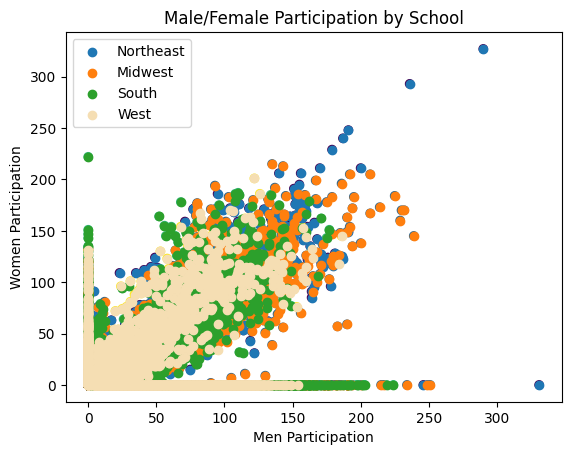

In [ ]:
#Scatterplot colored by region

#50 States + DC
state_to_region_numeric = {
    # Northeast
    'CT': 1, 'ME': 1, 'MA': 1, 'NH': 1, 'RI': 1, 'VT': 1,
    'NJ': 1, 'NY': 1, 'PA': 1,

    # Midwest
    'IL': 2, 'IN': 2, 'MI': 2, 'OH': 2, 'WI': 2,
    'IA': 2, 'KS': 2, 'MN': 2, 'MO': 2, 'NE': 2, 'ND': 2, 'SD': 2,

    # South
    'DE': 3, 'FL': 3, 'GA': 3, 'MD': 3, 'NC': 3, 'SC': 3, 'VA': 3, 'DC': 3,
    'WV': 3, 'AL': 3, 'KY': 3, 'MS': 3, 'TN': 3, 'AR': 3, 'LA': 3, 'OK': 3, 'TX': 3,

    # West
    'AZ': 4, 'CO': 4, 'ID': 4, 'MT': 4, 'NV': 4, 'NM': 4, 'UT': 4, 'WY': 4,
    'AK': 4, 'CA': 4, 'HI': 4, 'OR': 4, 'WA': 4
}
scatter_sports = sports_clean.fillna(0)
scatter_sports['region_name'] = scatter_sports['state_cd'].map(state_to_region_numeric)
plt.scatter(x=scatter_sports['sum_partic_men'], y=scatter_sports['sum_partic_women'], c=scatter_sports['region_name'])
plt.title('Male/Female Participation by School')
plt.xlabel('Men Participation')
plt.ylabel('Women Participation')
scatter_sports = sports_clean.fillna(0)
scatter_sports['region_name'] = scatter_sports['state_cd'].map(state_to_region_numeric)

northeast = scatter_sports[scatter_sports['region_name'] == 1]
midwest = scatter_sports[scatter_sports['region_name'] == 2]
south = scatter_sports[scatter_sports['region_name'] == 3]
west = scatter_sports[scatter_sports['region_name'] == 4]

plt.scatter(northeast['sum_partic_men'], northeast['sum_partic_women'], label='Northeast')
plt.scatter(midwest['sum_partic_men'], midwest['sum_partic_women'], label='Midwest')
plt.scatter(south['sum_partic_men'], south['sum_partic_women'], label='South')
plt.scatter(west['sum_partic_men'], west['sum_partic_women'], label='West',  color='wheat')
plt.legend()
plt.show()


   year  rev_per_male  rev_per_female
0  2015  21592.521552    14498.492493
1  2016  22394.184251    15297.424861
2  2017  23352.655844    15622.694819
3  2018  24048.741112    16746.757672
4  2019  23020.329699    15871.260514


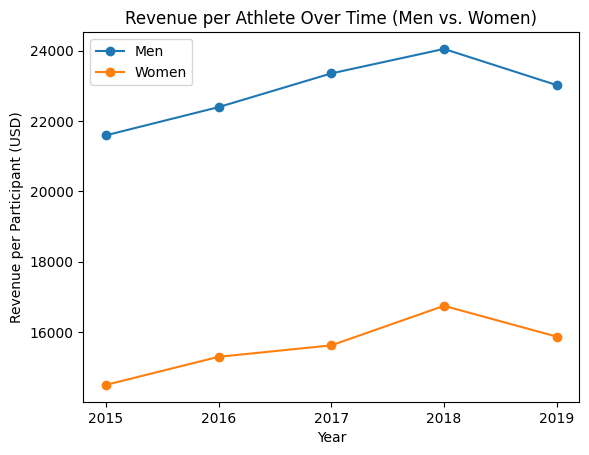

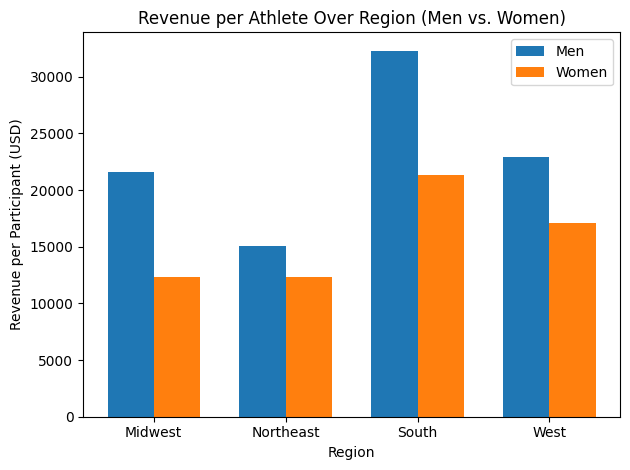

In [ ]:
# PARTICIPATION VS. REVENUE:

sports_partic_rev = sports_clean[(sports_clean['rev_men'] > 0) & (sports_clean['sum_partic_men'] > 0) &
                   (sports_clean['rev_women'] > 0) & (sports_clean['sum_partic_women'] > 0)].copy()

sports_partic_rev['rev_per_male'] = sports_partic_rev['rev_men'] / sports_partic_rev['sum_partic_men']
sports_partic_rev['rev_per_female'] = sports_partic_rev['rev_women'] / sports_partic_rev['sum_partic_women']

yearly_rev_partic = sports_partic_rev.groupby('year').agg({
    'rev_per_male': 'mean',
    'rev_per_female': 'mean'
}).reset_index()

region_rev_partic = sports_partic_rev.groupby('region_name').agg({
    'rev_per_male': 'mean',
    'rev_per_female': 'mean'
}).reset_index()


print(yearly_rev_partic)
plt.plot(yearly_rev_partic['year'], yearly_rev_partic['rev_per_male'], label='Men', marker='o')
plt.plot(yearly_rev_partic['year'], yearly_rev_partic['rev_per_female'], label='Women', marker='o')
plt.xlabel('Year')
plt.ylabel('Revenue per Participant (USD)')
plt.title('Revenue per Athlete Over Time (Men vs. Women)')
plt.legend()
plt.xticks(yearly_rev_partic['year'].unique())
plt.show()


x = np.arange(len(region_rev_partic['region_name']))  # numeric positions
width = 0.35  # width of each bar

plt.bar(x - width/2, region_rev_partic['rev_per_male'], width, label='Men')
plt.bar(x + width/2, region_rev_partic['rev_per_female'], width, label='Women')

plt.xlabel('Region')
plt.ylabel('Revenue per Participant (USD)')
plt.title('Revenue per Athlete Over Region (Men vs. Women)')
plt.xticks(x, region_rev_partic['region_name'])  # set region names at tick positions
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipython-input-3956077915.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sports_partic_rev = sports_clean_nofb[(sports_clean['rev_men'] > 0) & (sports_clean_nofb['sum_partic_men'] > 0) &


   year  rev_per_male  rev_per_female
0  2015  21592.521552    14498.492493
1  2016  22394.184251    15297.424861
2  2017  23352.655844    15622.694819
3  2018  24048.741112    16746.757672
4  2019  23020.329699    15871.260514


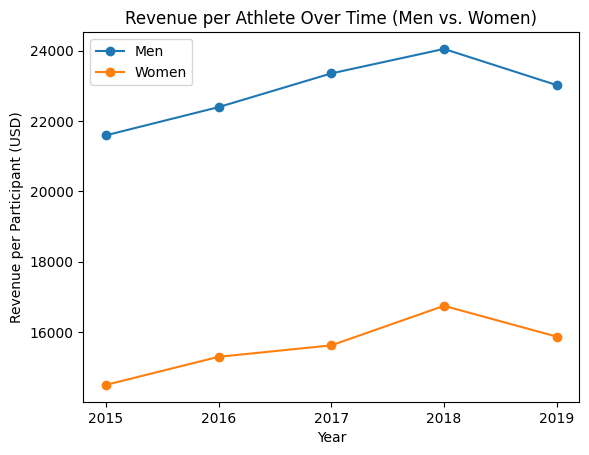

In [ ]:
# PARTICIPATION VS. REVENUE (no football):
sports_clean_nofb = sports_clean[sports_clean['sports'].str.lower() != 'football']
sports_partic_rev = sports_clean_nofb[(sports_clean['rev_men'] > 0) & (sports_clean_nofb['sum_partic_men'] > 0) &
                   (sports_clean_nofb['rev_women'] > 0) & (sports_clean_nofb['sum_partic_women'] > 0)].copy()

sports_partic_rev['rev_per_male'] = sports_partic_rev['rev_men'] / sports_partic_rev['sum_partic_men']
sports_partic_rev['rev_per_female'] = sports_partic_rev['rev_women'] / sports_partic_rev['sum_partic_women']

yearly_rev_partic = sports_partic_rev.groupby('year').agg({
    'rev_per_male': 'mean',
    'rev_per_female': 'mean'
}).reset_index()

region_rev_partic = sports_partic_rev.groupby('region_name').agg({
    'rev_per_male': 'mean',
    'rev_per_female': 'mean'
}).reset_index()


print(yearly_rev_partic)
plt.plot(yearly_rev_partic['year'], yearly_rev_partic['rev_per_male'], label='Men', marker='o')
plt.plot(yearly_rev_partic['year'], yearly_rev_partic['rev_per_female'], label='Women', marker='o')
plt.xlabel('Year')
plt.ylabel('Revenue per Participant (USD)')
plt.title('Revenue per Athlete Over Time (Men vs. Women)')
plt.legend()
plt.xticks(yearly_rev_partic['year'].unique())
plt.show()

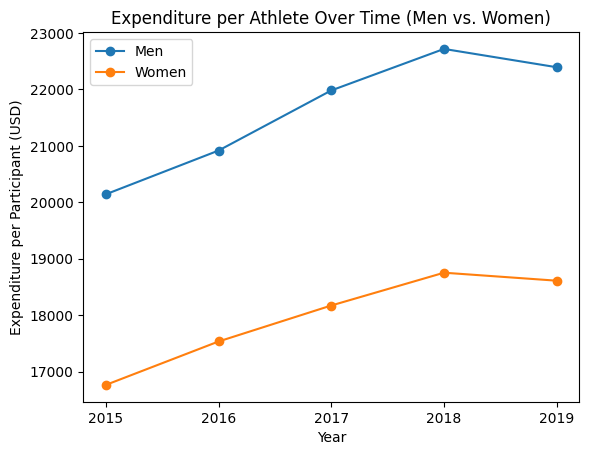

In [ ]:
# PARTICIPATION VS. EXPENDITURE:

sports_exp_rev = sports_clean[(sports_clean['exp_men'] > 0) & (sports_clean['sum_partic_men'] > 0) &
                   (sports_clean['exp_women'] > 0) & (sports_clean['sum_partic_women'] > 0)].copy()

sports_exp_rev['exp_per_male'] = sports_exp_rev['exp_men'] / sports_exp_rev['sum_partic_men']
sports_exp_rev['exp_per_female'] = sports_exp_rev['exp_women'] / sports_exp_rev['sum_partic_women']

yearly_exp_partic = sports_exp_rev.groupby('year').agg({
    'exp_per_male': 'mean',
    'exp_per_female': 'mean'
}).reset_index()

region_rev_partic = sports_exp_rev.groupby('region_name').agg({
    'exp_per_male': 'mean',
    'exp_per_female': 'mean'
}).reset_index()

plt.plot(yearly_exp_partic['year'], yearly_exp_partic['exp_per_male'], label='Men', marker='o')
plt.plot(yearly_exp_partic['year'], yearly_exp_partic['exp_per_female'], label='Women', marker='o')
plt.xlabel('Year')
plt.ylabel('Expenditure per Participant (USD)')
plt.title('Expenditure per Athlete Over Time (Men vs. Women)')
plt.legend()
plt.xticks(yearly_exp_partic['year'].unique())
plt.show()



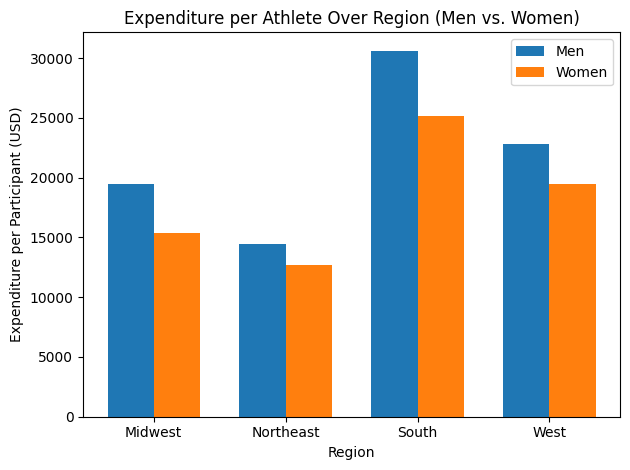

In [ ]:
#Expenditure by region
sports_exp_rev['region_name'] = sports_exp_rev['state_cd'].dropna().map(state_to_region)

region_exp_partic = sports_exp_rev.groupby('region_name').agg({
    'exp_per_male': 'mean',
    'exp_per_female': 'mean'
}).reset_index()
"""
plt.plot(region_exp_partic['region_name'], region_exp_partic['exp_per_male'], label='Men', marker='o')
plt.plot(region_exp_partic['region_name'], region_exp_partic['exp_per_female'], label='Women', marker='o')
plt.xlabel('Region')
plt.ylabel('Expenditure per Participant (USD)')
plt.title('Expenditure per Athlete Over Region (Men vs. Women)')
plt.legend()
plt.xticks(region_exp_partic['region_name'].unique())
plt.show()
"""
x = np.arange(len(region_exp_partic['region_name']))  # numeric positions
width = 0.35  # width of each bar

plt.bar(x - width/2, region_exp_partic['exp_per_male'], width, label='Men')
plt.bar(x + width/2, region_exp_partic['exp_per_female'], width, label='Women')

plt.xlabel('Region')
plt.ylabel('Expenditure per Participant (USD)')
plt.title('Expenditure per Athlete Over Region (Men vs. Women)')
plt.xticks(x, region_exp_partic['region_name'])  # set region names at tick positions
plt.legend()
plt.tight_layout()
plt.show()

   year  exp_per_male  exp_per_female  rev_per_male  rev_per_female
0  2015  13492.044896    13155.408189  14877.829971    11345.231213
1  2016  14102.710219    13741.542306  15515.880653    11961.531184
2  2017  14842.645707    14255.404213  16263.986202    12313.125835
3  2018  15399.380088    14739.977615  16751.688830    13076.245514
4  2019   4267.929107     4101.216473   4549.413097     3500.736008


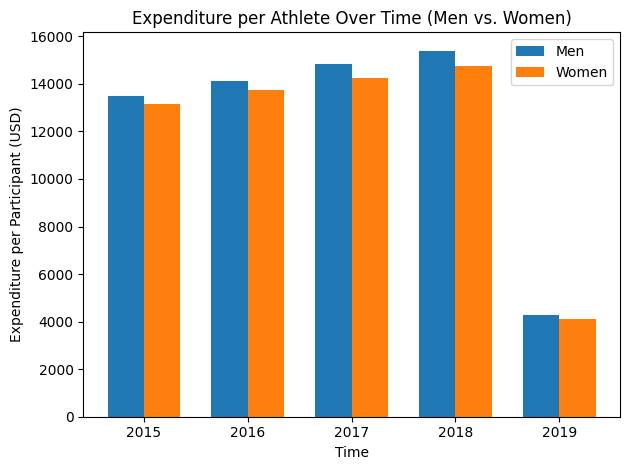

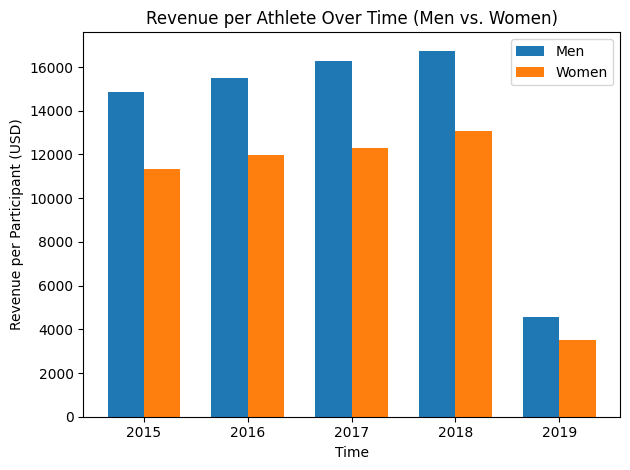

In [ ]:

sports_clean['exp_per_male'] = sports_clean['exp_men'] / sports_clean['sum_partic_men']
sports_clean['exp_per_female'] = sports_clean['exp_women'] / sports_clean['sum_partic_women']
sports_clean['rev_per_male'] = sports_clean['rev_men'] / sports_clean['sum_partic_men']
sports_clean['rev_per_female'] = sports_clean['rev_women'] / sports_clean['sum_partic_women']
sport_yearly_exp = sports_clean.fillna(0).groupby('year').agg({
    'exp_per_male': 'mean',
    'exp_per_female': 'mean',
    'rev_per_male': 'mean',
    'rev_per_female': 'mean'
}).reset_index()

print(sport_yearly_exp)

x = np.arange(len(sport_yearly_exp['year']))  # numeric positions
width = 0.35  # width of each bar

plt.bar(x - width/2, sport_yearly_exp['exp_per_male'], width, label='Men')
plt.bar(x + width/2, sport_yearly_exp['exp_per_female'], width, label='Women')

plt.xlabel('Time')
plt.ylabel('Expenditure per Participant (USD)')
plt.title('Expenditure per Athlete Over Time (Men vs. Women)')
plt.xticks(x, sport_yearly_exp['year'])  # set region names at tick positions
plt.legend()
plt.tight_layout()
plt.show()

x = np.arange(len(sport_yearly_exp['year']))  # numeric positions
width = 0.35  # width of each bar

plt.bar(x - width/2, sport_yearly_exp['rev_per_male'], width, label='Men')
plt.bar(x + width/2, sport_yearly_exp['rev_per_female'], width, label='Women')

plt.xlabel('Time')
plt.ylabel('Revenue per Participant (USD)')
plt.title('Revenue per Athlete Over Time (Men vs. Women)')
plt.xticks(x, sport_yearly_exp['year'])  # set region names at tick positions
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

cleaned_cols = [
    "year",
    "institution_name",
    "state_cd",
    "classification_name",
    "sports",
    "sum_partic_men",
    "sum_partic_women",
    "total_rev_menwomen"
]

cleaned_preview = sports[cleaned_cols].dropna().head(10)

output_path = "cleaned_dataset_preview.csv"
cleaned_preview.to_csv(output_path, index=False)


In [ ]:
# Regression for Total Revenue (numeric only)
cols = [
    "total_rev_menwomen",
    "sum_partic_men",
    "sum_partic_women",
    "classification_name",
    "sports",
    "year"
]
sports = sports[cols].dropna()


X_num = sports[["sum_partic_men", "sum_partic_women", "year"]]
y = sports["total_rev_menwomen"]

X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)

mA = LinearRegression()
mA.fit(X_train, y_train)
predA = mA.predict(X_test)

print("R squared:", round(r2_score(y_test, predA), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, predA)), 0))
print("Coefficients:", dict(zip(X_num.columns, mA.coef_)))



R squared: 0.079
RMSE: 3524608.0
Coefficients: {'sum_partic_men': np.float64(42613.05694472652), 'sum_partic_women': np.float64(-21053.195504906256), 'year': np.float64(26007.99045612025)}


In [ ]:
# Regression for Total Revenue (numeric + categorial)
X_full = sports[["sum_partic_men", "sum_partic_women", "year", "classification_name", "sports"]]

X_full = pd.get_dummies(X_full, columns=["classification_name", "sports"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

mB = LinearRegression()
mB.fit(X_train, y_train)
predB = mB.predict(X_test)

print("R squared:", round(r2_score(y_test, predB), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, predB)), 0))
print("\nTop 10 features by |coefficient|:", coefB.head(10))


R squared: 0.213
RMSE: 3258242.0


NameError: name 'coefB' is not defined